In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    "font.family": "serif",
    'mathtext.fontset': 'dejavuserif'
})

In [ ]:
def generate_spiral_data(num_samples: int):
    N = num_samples // 2

    theta = np.sqrt(np.random.rand(N))*4*np.pi

    r_a = 4*theta + np.pi
    data_a = np.array([np.cos(theta)*r_a, np.sin(theta)*r_a]).T
    x_a = data_a + np.random.randn(N,2) * 3
    label_a = np.array([0]*N)[:, None]


    r_b = -4*theta - np.pi
    data_b = np.array([np.cos(theta)*r_b, np.sin(theta)*r_b]).T
    x_b = data_b + np.random.randn(N,2) * 3
    label_b = np.array([1]*N)[:, None]

    x = np.concatenate([x_a, x_b], axis=0)
    x /= np.std(x, axis=0)
    y = np.concatenate([label_a, label_b], axis=0)
    return x, y.squeeze()

def plot_2d_data(x, y, edgecolors: str = None, alpha: float = 0.8):
    plt.figure()
    plt.scatter(x[:, 0], x[:, 1], c=y, cmap="magma", s=50, alpha=alpha, vmin=0.0, vmax=y.max()+1, edgecolors=edgecolors,)
    plt.axis('equal')
    plt.xlabel(r"$x_0$", fontdict={'family': 'serif', 'size': 14,  'color': 'black'})
    plt.ylabel(r"$x_1$", fontdict={'family': 'serif', 'size': 14,  'color': 'black'})
    plt.legend()
    plt.show()
    plt.close()

In [ ]:
x, y = generate_spiral_data(1000)

/tmp/ipykernel_382/227093569.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


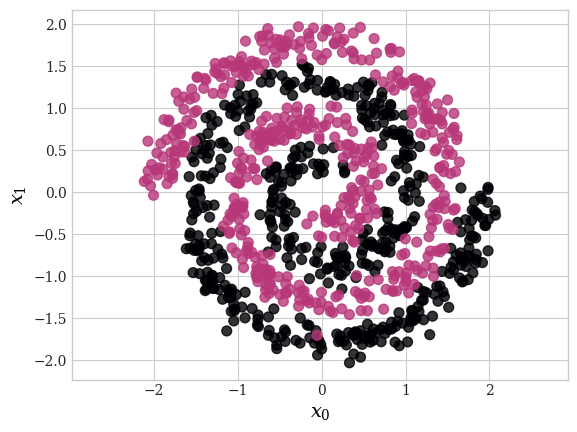

In [ ]:
plot_2d_data(x, y)

# Zadanie I:
- Zbuduj model o nazwie *backbone* $f_b: \mathbb{R}^d \to \mathbb{R}^d$ składający się z bloku warstw: Linear -> BatchNorm -> GELU.

- Zbuduj model o nazwie *head* $f_h: \mathbb{R}^d \to (0, 1)$ składający się z jednej warstwy **Linear** i aktywacji **Sigmoid**.

- Wytrenuj model $f = f_h \circ f_b$ na wygenerowanych danych używając lossu **BinaryCrossEntropy** i optimizera **Adam** lub **SGD**.

- Po treningu policz skuteczność (accuracy) modelu.

- Powtórz eskperyment zwiększając liczbę bloków w modelu *backbone* (1 - 3), tak aby wymiarowość warstw pośrednich wynosiła 20, a wejściowej i wyjściowej 2. Zapisz accuracy dla każdej konfiguracji.



In [ ]:
import torch
import torch.nn as nn
from torch import Tensor

# Zadanie II
- Dla *backbone* o głębokości 3 z poprzedniego zadania, zwizualizuj dane po przejściu przez *backbone* za pomocą:
```
plot_2d_data(backbone(x).detach(), y.detach())
```
- Dodatkowo, zwizualizuj granicę decyzji modelu head i nanieś ją na powyższą wizualizację. Jako granicę rozumiemy prostą:
```
head(x) = 0.5
```
poprzez sigmoide: $head(x) = \sigma(Wx+b)$ jest to hiperpłaszczyzna $Wx + b = 0$, gdzie $W$ i $b$ są parametrami *weight* i *bias* warstwy *Linear*. A że pracujemy w dwóch wymiarach to jest to prosta: $w_0x_0 + w_1x_1 + b = 0$, czyli $x_1 = -\dfrac{w_0x_0+b}{w_1}$


- Jaka wdł. Ciebie jest rola backbone i head w MLP na podstawie wizualizacji?

